# Day 7 — Module 2: Synthetic Data Population & Sampling Engines
**Programme:** C-DAC PGCP-AI | **Course:** Data Analytics
**Student / Author:** abs6187 (`23f2000876@ds.study.iitm.ac.in`)

### Core Objectives:
1. **Continuous & Discrete Generators:** Using NumPy modern Generator API (`np.random.default_rng(seed=42)`).
2. **Multi-Modal Population Simulation:** Simulating customer spend distributions with mixture models.
3. **Controlled Noise & Anomaly Injection:** Injecting sparse corrupted outliers and heavy-tailed noise.
4. **Goodness-of-Fit Testing:** Kolmogorov-Smirnov test (`scipy.stats.kstest`) and Q-Q Plot verification.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Recommended Modern NumPy Generator API
rng = np.random.default_rng(seed=42)

# ==============================================================================
# 1. GENERATING POPULATIONS FROM MULTIPLE DISTRIBUTIONS
# ==============================================================================
n_samples = 2000

# A. Gaussian Normal: Sensor temperature (mu=25°C, sigma=2°C)
pop_normal = rng.normal(loc=25.0, scale=2.0, size=n_samples)

# B. Continuous Uniform: Angle rotations [-15°, +15°]
pop_uniform = rng.uniform(low=-15.0, high=15.0, size=n_samples)

# C. Exponential: Customer call arrival intervals (scale=3.0 minutes)
pop_expon = rng.exponential(scale=3.0, size=n_samples)

# D. Poisson: Hourly website purchase transactions (lambda=8 transactions)
pop_poisson = rng.poisson(lam=8, size=n_samples)

print("=" * 65)
print("           SYNTHETIC DATA POPULATION SUMMARY                  ")
print("=" * 65)
print(f"Normal Population     : Mean={np.mean(pop_normal):.2f}, Std={np.std(pop_normal):.2f}")
print(f"Uniform Population    : Min={np.min(pop_uniform):.2f}, Max={np.max(pop_uniform):.2f}")
print(f"Exponential Population: Mean={np.mean(pop_expon):.2f}, Median={np.median(pop_expon):.2f}")
print(f"Poisson Population    : Mean={np.mean(pop_poisson):.2f}, Var={np.var(pop_poisson):.2f}")
print("=" * 65)


           SYNTHETIC DATA POPULATION SUMMARY                  
Normal Population     : Mean=24.89, Std=2.00
Uniform Population    : Min=-14.98, Max=14.99
Exponential Population: Mean=2.87, Median=1.99
Poisson Population    : Mean=8.04, Var=8.20


### 2. Multi-Modal Mixture Populations & Anomaly Injection
Real-world data rarely follows a single pure distribution. We simulate an E-Commerce customer transaction population with:
- **70% Budget Shoppers:** $\mathcal{N}(\mu=35, \sigma=8)$
- **30% Luxury Buyers:** $\mathcal{N}(\mu=120, \sigma=20)$
- **1% Fraudulent Cyber Anomalies:** Extreme outliers up to $\$500+$


        E-COMMERCE MIXTURE POPULATION WITH ANOMALIES          
Total Customers Simulated  : 5,000
Overall Mean Spend         : $65.48
Overall Median Spend       : $39.78
Injected Fraud Outliers    : 50 transactions ($400-$600)


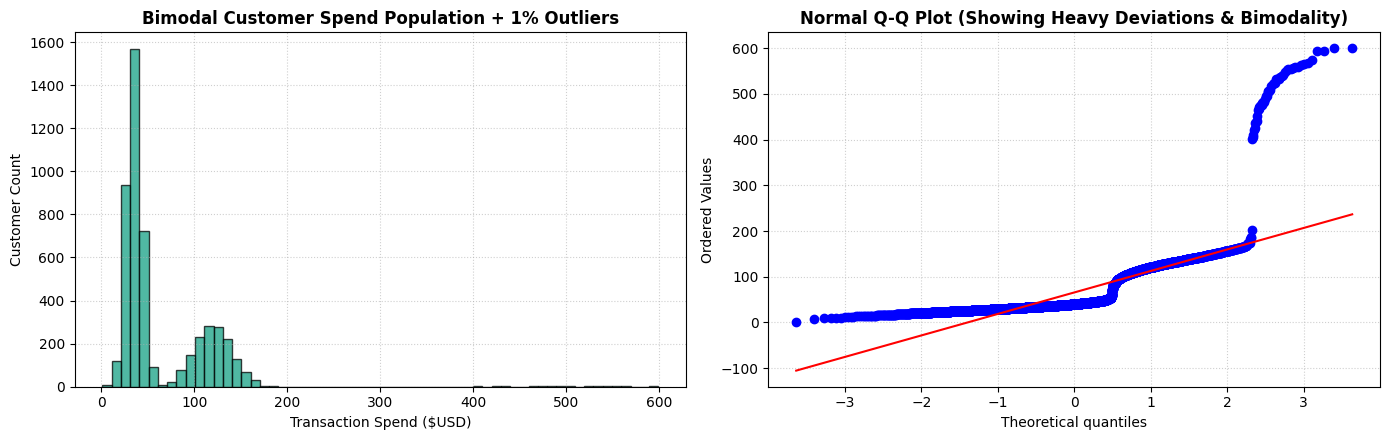

In [3]:
# 1. Mixture Model: 70% budget, 30% premium
n_pop = 5000
weights = rng.choice([0, 1], size=n_pop, p=[0.70, 0.30])

budget_spend = rng.normal(loc=35.0, scale=8.0, size=n_pop)
luxury_spend = rng.normal(loc=120.0, scale=20.0, size=n_pop)
mixture_spend = np.where(weights == 0, budget_spend, luxury_spend)

# 2. Inject 1% extreme anomalies (fraudulent chargebacks)
n_fraud = int(n_pop * 0.01)
fraud_indices = rng.choice(n_pop, size=n_fraud, replace=False)
mixture_spend[fraud_indices] = rng.uniform(400.0, 600.0, size=n_fraud)

# 3. Statistical Properties
print("=" * 65)
print("        E-COMMERCE MIXTURE POPULATION WITH ANOMALIES          ")
print("=" * 65)
print(f"Total Customers Simulated  : {n_pop:,}")
print(f"Overall Mean Spend         : ${np.mean(mixture_spend):.2f}")
print(f"Overall Median Spend       : ${np.median(mixture_spend):.2f}")
print(f"Injected Fraud Outliers    : {n_fraud} transactions ($400-$600)")
print("=" * 65)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Subplot 1: Histogram
axes[0].hist(mixture_spend, bins=60, color='#16a085', edgecolor='black', alpha=0.75)
axes[0].set_title('Bimodal Customer Spend Population + 1% Outliers', fontweight='bold')
axes[0].set_xlabel('Transaction Spend ($USD)')
axes[0].set_ylabel('Customer Count')
axes[0].grid(True, linestyle=':', alpha=0.6)

# Subplot 2: Q-Q Plot against Normal
stats.probplot(mixture_spend, dist='norm', plot=axes[1])
axes[1].set_title('Normal Q-Q Plot (Showing Heavy Deviations & Bimodality)', fontweight='bold')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()
